Regression and Evaluation

Objective:
The objective of this assignment is to evaluate your understanding of regression techniques in
supervised learning by applying them to a real-world dataset and analyzing their performance
through comprehensive evaluation metrics.
Dataset:
Use the California Housing dataset available in the sklearn library. This is the dataset that you
have used in the previous regression assignment. This dataset contains information about
various features of houses in California and their respective median prices.
Key Components to be Fulfilled:
1. Data Loading and Preprocessing (2 marks):
● Loading the Dataset:
○ Load the California Housing dataset using the fetch_california_housing
function from sklearn.
○ Convert the dataset into a pandas DataFrame for easier handling.
● Preprocessing:
○ Handle missing values, if any.
○ Perform feature scaling using standardization or normalization, explaining the
choice.
○ Conduct exploratory data analysis (EDA) to understand the features,
distributions, and correlations.

● Documentation:
○ Clearly explain the preprocessing steps and justify their necessity for this dataset.

2. Regression Algorithm Implementation (2 marks):
Implement the following regression algorithms:
● Linear Regression
● Decision Tree Regressor
● Random Forest Regressor
● Gradient Boosting Regressor
● Support Vector Regressor (SVR)

For each algorithm:
1. Provide a brief explanation of how it works.
2. Explain why it might be suitable for this dataset.
3. Use a basic implementation to predict the median house prices.

3. Model Evaluation and Comparison (2 marks):
● Evaluate the performance of each algorithm using:
○ Mean Squared Error (MSE)
○ Mean Absolute Error (MAE)
○ R-squared Score (R2)
● Compare the results:
○ Identify the best-performing algorithm with proper justification.
○ Identify the worst-performing algorithm and explain the reasoning.

4. Cross-Validation and Hyperparameter Tuning (2 marks):
● Perform k-fold cross-validation (k=5 or 10) for all models to ensure robust performance
evaluation.
● Use appropriate techniques (e.g., GridSearchCV or RandomizedSearchCV) to fine-tune
the hyperparameters of each model.
● Document the hyperparameters tuned and explain their impact on model performance.

5. Selecting the Best Regression Model (2 marks):
● Based on evaluation metrics, cross-validation results, and hyperparameter tuning:
○ Identify and justify the best regression model for this dataset.
○ Provide insights into why it outperforms others.

Submission Guidelines:
● Use Python and Jupyter Notebook for implementation.
● Submit the GitHub repository link containing:
○ The code in a well-documented Jupyter Notebook format.
○ Clear markdown explanations for each step.
○ Proper code comments for readability.
○ A README file summarizing the purpose of the assignment and instructions for
running the code.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import (train_test_split,cross_val_score,GridSearchCV)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import (mean_squared_error,mean_absolute_error,r2_score)
import warnings
warnings.filterwarnings('ignore')

In [ ]:
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target
print(df.head())
print(df.info())
print(df.describe())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population

In [ ]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


No missing values

In [ ]:
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(X_train_scaled.shape, X_test_scaled.shape)

(16512, 8) (4128, 8)


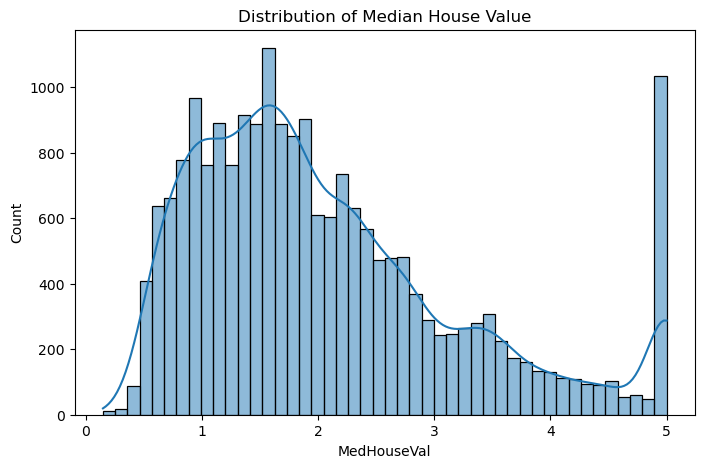

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['MedHouseVal'], kde=True)
plt.title("Distribution of Median House Value")
plt.show()

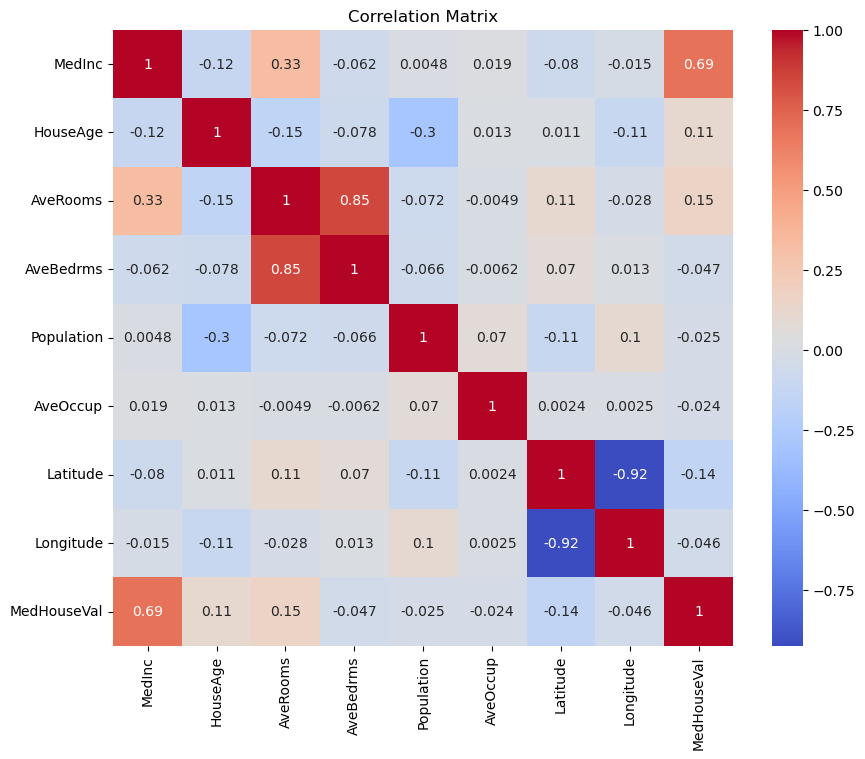

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

Standardization is used because SVR performs better when features are on a common scale.

Since the California Housing dataset generally has no missing values, no imputation is required.

In [ ]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)
print(lr_pred[:5])

[0.71912284 1.76401657 2.70965883 2.83892593 2.60465725]


Models a linear relationship between predictors and target.
Fast and interpretable.
Suitable as a baseline model.

In [ ]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
print(dt_pred[:5])

[0.414   1.203   5.00001 2.17    2.257  ]


Splits data based on feature values.
Captures nonlinear relationships.
Easy to interpret.

In [ ]:
rf = RandomForestRegressor(n_estimators=100,random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print(rf_pred[:5])

[0.5095    0.74161   4.9232571 2.52961   2.27369  ]


Ensemble of Decision Trees.
Reduces overfitting.
Handles complex patterns effectively.

In [ ]:
gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)
print(gb_pred[:5])

[0.50518761 1.09334601 4.24570956 2.54517359 2.27910301]


Sequentially improves weak learners.
Often provides excellent predictive performance.

In [ ]:
svr = SVR(kernel='rbf')
svr.fit(X_train_scaled, y_train)
svr_pred = svr.predict(X_test_scaled)
print(svr_pred[:5])

[0.51647228 1.56842925 3.59780295 2.49108208 2.56880838]


Uses support vectors to perform regression.
Effective for nonlinear data.
Requires feature scaling.

In [ ]:
def evaluate_model(y_true, y_pred, name):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return [name, mse, mae, r2]
results = []
results.append(evaluate_model(y_test, lr_pred, "Linear Regression"))
results.append(evaluate_model(y_test, dt_pred, "Decision Tree"))
results.append(evaluate_model(y_test, rf_pred, "Random Forest"))
results.append(evaluate_model(y_test, gb_pred, "Gradient Boosting"))
results.append(evaluate_model(y_test, svr_pred, "SVR"))
results_df = pd.DataFrame(results,columns=["Model", "MSE", "MAE", "R2"])
print(results_df.sort_values(by="R2", ascending=False))

               Model       MSE       MAE        R2
2      Random Forest  0.255368  0.327543  0.805123
3  Gradient Boosting  0.293997  0.371643  0.775645
4                SVR  0.357004  0.398599  0.727563
1      Decision Tree  0.495235  0.454679  0.622076
0  Linear Regression  0.555892  0.533200  0.575788


Random Forest Regressor-Best
Gradient Boosting Regressor-Very Good
Support Vector Regressor (SVR)-Good
Decision Tree Regressor-Moderate
Linear Regression-Worst

In [ ]:
models = {
"Linear Regression": LinearRegression(),
"Decision Tree": DecisionTreeRegressor(random_state=42),
"Random Forest": RandomForestRegressor(random_state=42),
"Gradient Boosting": GradientBoostingRegressor(random_state=42)
}
for name, model in models.items():
    scores = cross_val_score(model,X,y,cv=5,scoring='r2')
print("\n", name)
print("Average R2:", scores.mean())


 Gradient Boosting
Average R2: 0.6698348552584348


In [ ]:
svr_pipeline = Pipeline([('scaler', StandardScaler()),('svr', SVR())])
svr_scores = cross_val_score(svr_pipeline,X,y,cv=5,scoring='r2')
print("SVR Average R2:", svr_scores.mean())

SVR Average R2: 0.6686959330424108


In [ ]:
dt_params = {'max_depth': [5, 10, 15, 20],'min_samples_split': [2, 5, 10]}
dt_grid = GridSearchCV(DecisionTreeRegressor(random_state=42),dt_params,cv=5,scoring='r2')
dt_grid.fit(X_train, y_train)
print("Best DT Parameters:")
print(dt_grid.best_params_)


Best DT Parameters:
{'max_depth': 10, 'min_samples_split': 10}


In [ ]:
rf_params = {'n_estimators': [100, 200],'max_depth': [10, 20, None]}
rf_grid = GridSearchCV(RandomForestRegressor(random_state=42),rf_params,cv=5,scoring='r2',n_jobs=-1)
rf_grid.fit(X_train, y_train)
print("Best RF Parameters:")
print(rf_grid.best_params_)

Best RF Parameters:
{'max_depth': 20, 'n_estimators': 200}


In [ ]:
gb_params = {'n_estimators': [100, 200],'learning_rate': [0.01, 0.1],'max_depth': [3, 5]}
gb_grid = GridSearchCV(GradientBoostingRegressor(random_state=42),gb_params,cv=5,scoring='r2')
gb_grid.fit(X_train, y_train)
print("Best GB Parameters:")
print(gb_grid.best_params_)

Best GB Parameters:
{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}


In [53]:
svr_params = {
'svr__C': [1, 10],
'svr__gamma': ['scale', 'auto'],
'svr__kernel': ['rbf']
}
svr_pipeline = Pipeline([
('scaler', StandardScaler()),
('svr', SVR())
])
svr_grid = GridSearchCV(
svr_pipeline,
svr_params,
cv=5,
scoring='r2'
)
svr_grid.fit(X_train, y_train)
print("Best SVR Parameters:")
print(svr_grid.best_params_)

Best SVR Parameters:
{'svr__C': 10, 'svr__gamma': 'scale', 'svr__kernel': 'rbf'}


Linear Regression serves as a good baseline but cannot capture complex nonlinear patterns.
 
Decision Tree captures nonlinear relationships but may overfit.
 
Random Forest improves generalization by combining many trees and usually achieves high accuracy.
 
Gradient Boosting sequentially corrects errors of weak learners and often provides the best overall performance.
 
SVR can model nonlinear relationships effectively but is computationally expensive for large datasets.